<a href="https://colab.research.google.com/github/thisisShreya/part-2-cnn-computer-vision/blob/main/notebook2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Extracted
Dataset Directory: /content/dataset/part_2_cnn_computer_vision/images

Classes Found:
['normal', 'stain', 'dent', 'scratch']

Images Per Class:
{'normal': 120, 'stain': 120, 'dent': 120, 'scratch': 120}


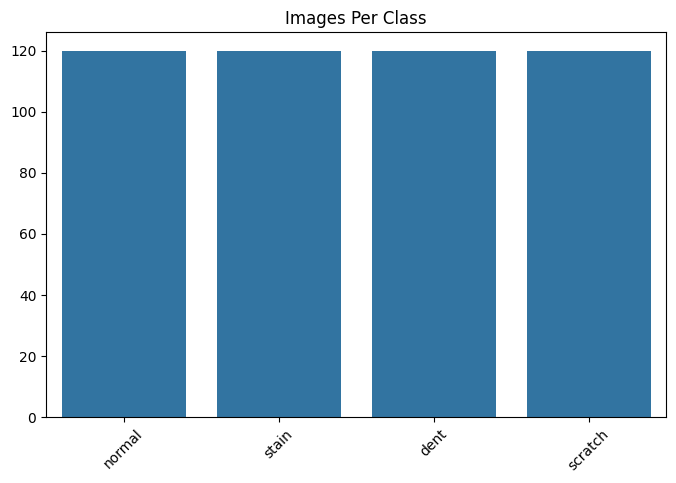

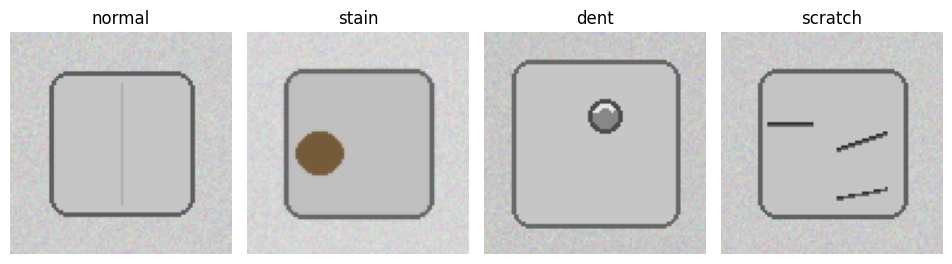

Found 384 images belonging to 4 classes.
Found 96 images belonging to 4 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
12/12 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.2214 - loss: 2.1254 - val_accuracy: 0.2500 - val_loss: 1.3872
Epoch 2/5
12/12 ━━━━━━━━━━━━━━━━━━━━ 12s 971ms/step - accuracy: 0.2344 - loss: 1.3891 - val_accuracy: 0.2812 - val_loss: 1.3700
Epoch 3/5
12/12 ━━━━━━━━━━━━━━━━━━━━ 12s 970ms/step - accuracy: 0.3828 - loss: 1.3447 - val_accuracy: 0.4062 - val_loss: 1.2694
Epoch 4/5
12/12 ━━━━━━━━━━━━━━━━━━━━ 12s 969ms/step - accuracy: 0.4922 - loss: 1.1885 - val_accuracy: 0.3646 - val_loss: 1.1969
Epoch 5/5
12/12 ━━━━━━━━━━━━━━━━━━━━ 12s 992ms/step - accuracy: 0.5417 - loss: 1.0267 - val_accuracy: 0.6667 - val_loss: 0.8718


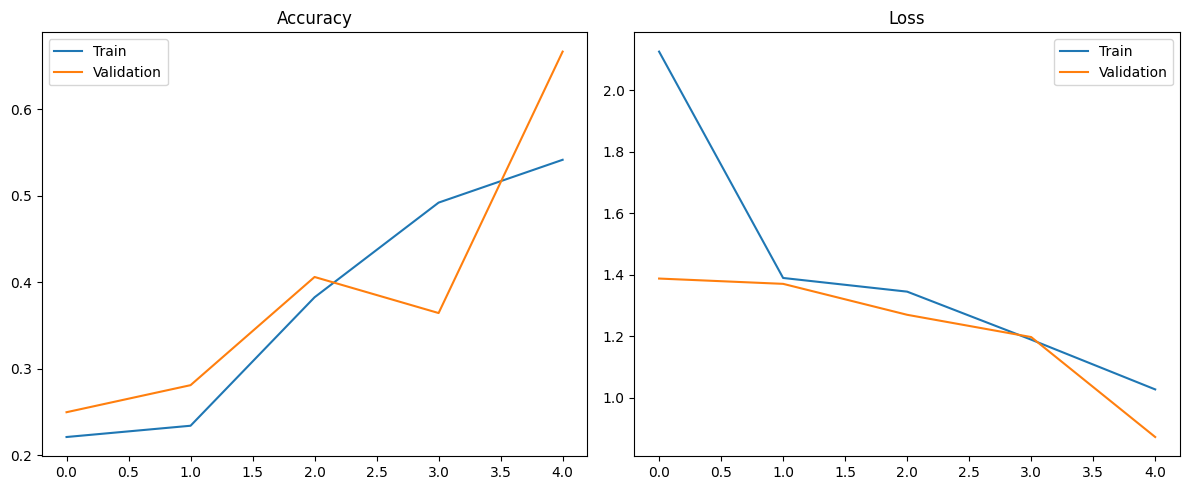

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 361ms/step - accuracy: 0.6771 - loss: 0.9179

Validation Accuracy: 0.6770833134651184
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 438ms/step


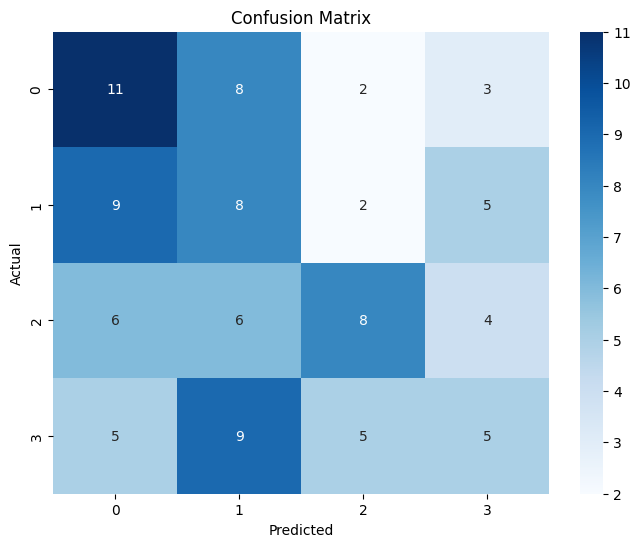


Classification Report:

              precision    recall  f1-score   support

        dent       0.35      0.46      0.40        24
      normal       0.26      0.33      0.29        24
     scratch       0.47      0.33      0.39        24
       stain       0.29      0.21      0.24        24

    accuracy                           0.33        96
   macro avg       0.34      0.33      0.33        96
weighted avg       0.34      0.33      0.33        96

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 259ms/step


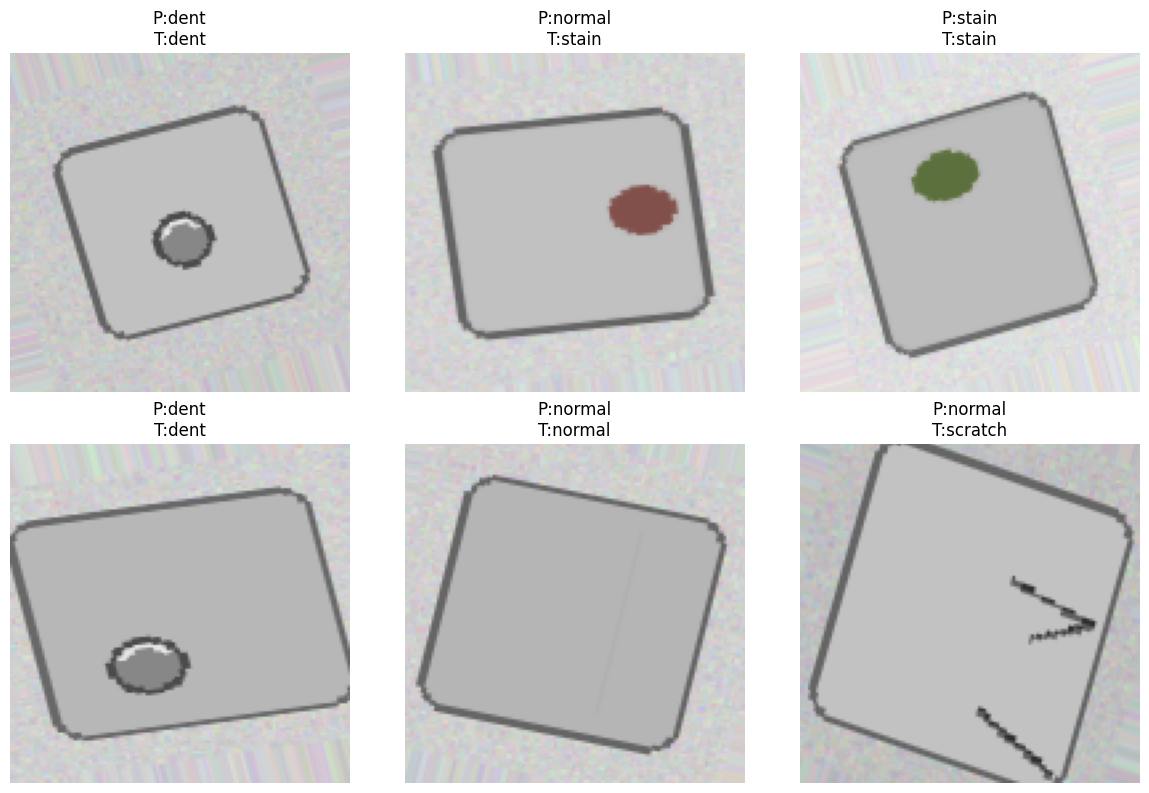

In [ ]:
# =========================
# IMPORT LIBRARIES
# =========================

import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# =========================
# EXTRACT ZIP FILE
# =========================

zip_path = '/content/part_2_cnn_computer_vision-20260517T103529Z-3-001.zip'

extract_path = '/content/dataset'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset Extracted")

# =========================
# FIND DATASET DIRECTORY
# =========================

# Assuming the zip extracts to /content/dataset/part_2_cnn_computer_vision/images/<class_name>/image.jpg
# We need to find the base directory that contains the class folders.

initial_dataset_root = extract_path # Start from the extracted path
dataset_dir = initial_dataset_root

# Walk through the extracted directory to find the actual directory containing class folders
for root, dirs, files in os.walk(initial_dataset_root):
    # If an 'images' directory is found that contains subdirectories (actual classes)
    if 'images' in dirs:
        potential_classes_path = os.path.join(root, 'images')
        # Check if potential_classes_path actually contains subdirectories
        if any(os.path.isdir(os.path.join(potential_classes_path, d)) for d in os.listdir(potential_classes_path)):
            dataset_dir = potential_classes_path
            break
    # If no 'images' dir, but the current root itself contains subdirectories (actual classes)
    elif dirs and root != initial_dataset_root: # To avoid picking just the wrapper folder at the very top
        if any(os.path.isdir(os.path.join(root, d)) for d in os.listdir(root)):
            dataset_dir = root
            break

print("Dataset Directory:", dataset_dir)

# =========================
# DATASET EXPLORATION
# =========================

classes = [cls for cls in os.listdir(dataset_dir) if os.path.isdir(os.path.join(dataset_dir, cls)) and not cls.startswith('.')]

print("\nClasses Found:")
print(classes)

class_counts = {}

# Define common image extensions for filtering
IMAGE_EXTENSIONS = ('.png', '.jpg', '.jpeg', '.gif', '.bmp', '.tiff')

for cls in classes:
    class_path = os.path.join(dataset_dir, cls)

    if os.path.isdir(class_path):
        # Filter for actual image files by checking extension and if it's a file
        image_files = [f for f in os.listdir(class_path) if not f.startswith('.') and os.path.isfile(os.path.join(class_path, f)) and f.lower().endswith(IMAGE_EXTENSIONS)]
        class_counts[cls] = len(image_files)

print("\nImages Per Class:")
print(class_counts)

# =========================
# PLOT CLASS DISTRIBUTION
# =========================

plt.figure(figsize=(8,5))
sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()))
plt.title("Images Per Class")
plt.xticks(rotation=45)
plt.show()

# =========================
# DISPLAY SAMPLE IMAGES
# =========================

plt.figure(figsize=(12,8))

i = 1

for cls in classes:

    class_path = os.path.join(dataset_dir, cls)

    if os.path.isdir(class_path):

        # Filter for actual image files by checking extension and if it's a file
        image_files = [f for f in os.listdir(class_path) if not f.startswith('.') and os.path.isfile(os.path.join(class_path, f)) and f.lower().endswith(IMAGE_EXTENSIONS)]

        if not image_files: # Skip if no valid images found in the class
            continue

        image_name = image_files[0]

        image_path = os.path.join(class_path, image_name)

        img = Image.open(image_path)

        plt.subplot(2, 5, i)
        plt.imshow(img)
        plt.title(cls)
        plt.axis('off')

        i += 1

plt.tight_layout()
plt.show()

# =========================
# IMAGE PREPROCESSING
# =========================

img_size = (128, 128)
batch_size = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

train_data = datagen.flow_from_directory(
    dataset_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_data = datagen.flow_from_directory(
    dataset_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

# =========================
# CNN MODEL
# =========================

model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu',
                 input_shape=(128,128,3)))

model.add(MaxPooling2D(2,2))

model.add(Conv2D(64, (3,3), activation='relu'))

model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(128, activation='relu'))

model.add(Dense(train_data.num_classes, activation='softmax'))

# =========================
# COMPILE MODEL
# =========================

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# =========================
# TRAIN MODEL
# =========================

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

# =========================
# PLOT ACCURACY & LOSS
# =========================

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Accuracy')
plt.legend(['Train','Validation'])

plt.subplot(1,2,2)

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Loss')
plt.legend(['Train','Validation'])

plt.tight_layout()
plt.show()

# =========================
# EVALUATION
# =========================

loss, accuracy = model.evaluate(val_data)

print("\nValidation Accuracy:", accuracy)

# =========================
# PREDICTIONS
# =========================

predictions = model.predict(val_data)

y_pred = np.argmax(predictions, axis=1)

y_true = val_data.classes

# =========================
# CONFUSION MATRIX
# =========================

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# =========================
# CLASSIFICATION REPORT
# =========================

print("\nClassification Report:\n")

print(classification_report(
    y_true,
    y_pred,
    target_names=list(val_data.class_indices.keys())
))

# =========================
# SAMPLE PREDICTIONS
# =========================

plt.figure(figsize=(12,8))

images, labels = next(val_data)

preds = model.predict(images)

for i in range(6):

    plt.subplot(2,3,i+1)

    plt.imshow(images[i])

    pred_label = np.argmax(preds[i])

    true_label = np.argmax(labels[i])

    class_names = list(val_data.class_indices.keys())

    plt.title(f"P:{class_names[pred_label]}\nT:{class_names[true_label]}")

    plt.axis('off')

plt.tight_layout()
plt.show()